In [1]:
# Import required libraries & ML models & evaluation metrics

import opensim
import sys
import opensim as osim
import numpy as np
from pathlib import Path
import numpy as np
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
import joblib
from sklearn.neural_network import MLPRegressor

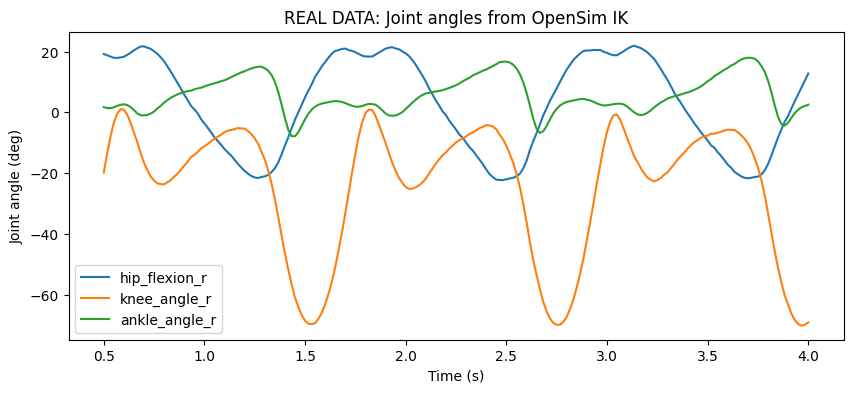

In [3]:
# Load and plot real joint angles from OpenSim IK

def read_mot_or_sto(path):
    lines = Path(path).read_text().splitlines()
    end = 0
    for i, line in enumerate(lines):
        if "endheader" in line.lower():
            end = i + 1
            break
    data = "\n".join(lines[end:])
    return pd.read_csv(StringIO(data), sep=r"\s+", engine="python")

# path to REAL data
mot_path = Path(
    "/Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/"
    "Pipelines/Gait2392_Simbody/subject01_walk1_ik.mot"
)

ik_df = read_mot_or_sto(mot_path)

real_cols = ["hip_flexion_r", "knee_angle_r", "ankle_angle_r"]

plt.figure(figsize=(10,4))
for c in real_cols:
    plt.plot(ik_df["time"], ik_df[c], label=c)

plt.xlabel("Time (s)")
plt.ylabel("Joint angle (deg)")
plt.title("REAL DATA: Joint angles from OpenSim IK")
plt.legend()
plt.show()


In [5]:
# Load OpenSim model and initialize system

model_path = "/Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Models/Gait2392_Simbody/subject01_adjusted.osim"
model = osim.Model(model_path)
state = model.initSystem()

print("Model loaded successfully")
print("Number of coordinates:", model.getCoordinateSet().getSize())


[info] Updating Model file from 40000 to latest format...
Model loaded successfully
Number of coordinates: 23
[info] Loaded model subject01 from file /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Models/Gait2392_Simbody/subject01_adjusted.osim
[warning] Couldn't find file 'treadmill.vtp'.
[warning] Couldn't find file 'sacrum.vtp'.
[warning] Couldn't find file 'pelvis.vtp'.
[warning] Couldn't find file 'l_pelvis.vtp'.
[warning] Couldn't find file 'femur_r.vtp'.
[warning] Couldn't find file 'tibia_r.vtp'.
[warning] Couldn't find file 'fibula.vtp'.
[warning] Couldn't find file 'talus.vtp'.
[warning] Couldn't find file 'foot.vtp'.
[warning] Couldn't find file 'bofoot.vtp'.
[warning] Couldn't find file 'femur_l.vtp'.
[warning] Couldn't find file 'tibia_l.vtp'.
[warning] Couldn't find file 'l_fibula.vtp'.
[warning] Couldn't find file 'l_talus.vtp'.
[warning] Couldn't find file 'l_foot.vtp'.
[warning] Couldn't find file 'l_bofoot.vtp'.
[warning] Couldn't find file 'hat_spin

In [7]:
# List the available joint coordinates

coord_set = model.getCoordinateSet()

print("Available coordinates:")
for i in range(coord_set.getSize()):
    coord = coord_set.get(i)
    print(f"- {coord.getName()}")


Available coordinates:
- pelvis_tilt
- pelvis_list
- pelvis_rotation
- pelvis_tx
- pelvis_ty
- pelvis_tz
- hip_flexion_r
- hip_adduction_r
- hip_rotation_r
- knee_angle_r
- ankle_angle_r
- subtalar_angle_r
- mtp_angle_r
- hip_flexion_l
- hip_adduction_l
- hip_rotation_l
- knee_angle_l
- ankle_angle_l
- subtalar_angle_l
- mtp_angle_l
- lumbar_extension
- lumbar_bending
- lumbar_rotation


In [9]:
# List the available body segments

body_set = model.getBodySet()

print("Available bodies:")
for i in range(body_set.getSize()):
    body = body_set.get(i)
    print(f"- {body.getName()}")


Available bodies:
- pelvis
- femur_r
- tibia_r
- talus_r
- calcn_r
- toes_r
- femur_l
- tibia_l
- talus_l
- calcn_l
- toes_l
- torso


In [11]:
# Select IMU body segments

pelvis = model.getBodySet().get("pelvis")
tibia_r = model.getBodySet().get("tibia_r")

print("Selected bodies:", pelvis.getName(), tibia_r.getName())

Selected bodies: pelvis tibia_r


In [13]:
# Search in the  project directory for OpenSim .mot and .sto files

project_dir = Path("/Users/mostafahekal/Downloads/MMLA Project/opensim-models-master")

mot_files = list(project_dir.rglob("*.mot"))
sto_files = list(project_dir.rglob("*.sto"))

print("MOT files:", len(mot_files))
for f in mot_files[:20]:
    print("  ", f)

print("\nSTO files:", len(sto_files))
for f in sto_files[:20]:
    print("  ", f)

print("OSIM:", list(project_dir.rglob("*.osim"))[:5])
print("MOT :", list(project_dir.rglob("*.mot"))[:5])
print("STO :", list(project_dir.rglob("*.sto"))[:5])

MOT files: 40
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait10dof18musc/OutputReference/ExperimentalData/subject01_walk_grf.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait10dof18musc/OutputReference/IK/subject01_walk_IK.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait10dof18musc/ExperimentalData/subject01_walk_grf.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2354_Simbody/subject01_walk1_ik.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2354_Simbody/subject01_walk1_grf.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2354_Simbody/OutputReference/subject01_static_output.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2354_Simbody/OutputReference/subject01_walk1_ik.mot
   /Users/mostafahekal/Downloads/MMLA Project/opensim-mod

In [15]:
# Select pipeline, IK motion, and OSIM model

root = Path("/Users/mostafahekal/Downloads/MMLA Project/opensim-models-master")

# Choose one pipeline 
pipeline = root / "Pipelines" / "Gait2392_Simbody"

# pick IK motion
mot_path = pipeline / "subject01_walk1_ik.mot"

# find an .osim in that pipeline folder
osim_candidates = list(pipeline.rglob("*.osim"))
print("Found OSIM candidates:")
for p in osim_candidates[:10]:
    print(" ", p)

print("\nChosen MOT:", mot_path)
print("MOT exists?", mot_path.exists())


Found OSIM candidates:
  /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2392_Simbody/OutputReference/subject01_simbody.osim
  /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2392_Simbody/OutputReference/subject01_simbody_adjusted.osim

Chosen MOT: /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2392_Simbody/subject01_walk1_ik.mot
MOT exists? True


In [101]:
# Load IK motion data and list available columns

motion = osim.Storage(str(mot_path))
labels = motion.getColumnLabels()

print("Loaded motion")
print("Columns:", labels.getSize())


Loaded motion
Columns: 24
[info] Storage: read data file = /Users/mostafahekal/Downloads/MMLA Project/opensim-models-master/Pipelines/Gait2392_Simbody/subject01_walk1_ik.mot (nr=211 nc=24)


In [21]:
# Apply IK motion frame to model state

coord_set = model.getCoordinateSet()

def apply_motion_row_to_model(model, state, labels, values):
    # values is the array from Storage state vector data (not including time)
    data_idx = 0
    for i in range(labels.getSize()):
        name = labels.get(i)
        if name == "time":
            continue

        if coord_set.contains(name):
            coord_set.get(name).setValue(state, values[data_idx], False)

        data_idx += 1

    model.realizePosition(state)

# take a sample frame
sv = motion.getStateVector(10)         
data = sv.getData()             
vals = [data.get(i) for i in range(data.size())]

apply_motion_row_to_model(model, state, labels, vals)
print("Applied IK at time:", sv.getTime())


Applied IK at time: 0.66666667


In [23]:
#body orientation in ground (rotation matrix)

def get_R_GB(model, state, body_name: str):
    """
    Returns rotation matrix R_GB (3x3): Ground <- Body
    """
    body = model.getBodySet().get(body_name)
    X_GB = body.getTransformInGround(state)
    R = X_GB.R()
    R_np = np.array([
        [R.get(0,0), R.get(0,1), R.get(0,2)],
        [R.get(1,0), R.get(1,1), R.get(1,2)],
        [R.get(2,0), R.get(2,1), R.get(2,2)]
    ])
    return R_np

In [25]:
#Compute angular velocity from rotation

def skew_to_omega(S):
    # S is 3x3 skew-symmetric
    return np.array([S[2,1], S[0,2], S[1,0]])

def gyro_from_R(R_t, R_next, dt):
    dR = (R_next - R_t) / dt
    Omega = dR @ R_t.T  # approx skew
    return skew_to_omega(Omega)  # rad/s


In [27]:
#body origin position in ground (for accel)

def get_p_G(model, state, body_name: str):
    body = model.getBodySet().get(body_name)
    X_GB = body.getTransformInGround(state)
    p = X_GB.p()
    return np.array([p.get(0), p.get(1), p.get(2)])


In [29]:
#Compute acceleration via finite differences from positions

def accel_from_positions(p_prev, p_t, p_next, dt):
    return (p_next - 2*p_t + p_prev) / (dt**2)  # m/s^2


In [31]:
#Loop over motion frames and extract IMU signals

imu_bodies = ["pelvis", "tibia_r"]

labels = motion.getColumnLabels()

N = motion.getSize()
times = []
gyro = {b: [] for b in imu_bodies}
acc  = {b: [] for b in imu_bodies}

# we need at least 3 frames for acceleration (prev, t, next)
for k in range(1, N-1):
    sv_prev = motion.getStateVector(k-1)
    sv      = motion.getStateVector(k)
    sv_next = motion.getStateVector(k+1)

    dt = sv_next.getTime() - sv.getTime()
    if dt <= 0:
        continue

    # apply pose at k-1, k, k+1 and compute body transforms
    def apply_sv(sv):
        data = sv.getData()
        vals = [data.get(i) for i in range(data.size())]
        apply_motion_row_to_model(model, state, labels, vals)

    apply_sv(sv_prev)
    model.realizePosition(state)
    R_prev = {b: get_R_GB(model, state, b) for b in imu_bodies}
    p_prev = {b: get_p_G(model, state, b) for b in imu_bodies}

    apply_sv(sv)
    model.realizePosition(state)
    R_t = {b: get_R_GB(model, state, b) for b in imu_bodies}
    p_t = {b: get_p_G(model, state, b) for b in imu_bodies}

    apply_sv(sv_next)
    model.realizePosition(state)
    R_next = {b: get_R_GB(model, state, b) for b in imu_bodies}
    p_next = {b: get_p_G(model, state, b) for b in imu_bodies}

    times.append(sv.getTime())

    for b in imu_bodies:
        gyro[b].append(gyro_from_R(R_t[b], R_next[b], dt))
        acc[b].append(accel_from_positions(p_prev[b], p_t[b], p_next[b], dt))

times = np.array(times)
for b in imu_bodies:
    gyro[b] = np.vstack(gyro[b])  # shape (T,3)
    acc[b]  = np.vstack(acc[b])   # shape (T,3)

print("times:", times.shape)
for b in imu_bodies:
    print(b, "gyro", gyro[b].shape, "acc", acc[b].shape)


times: (209,)
pelvis gyro (209, 3) acc (209, 3)
tibia_r gyro (209, 3) acc (209, 3)


In [33]:
#Convert your IMU signals into one feature matrix

imu_bodies = ["pelvis", "tibia_r"]  # keep same as your code

# build a dataframe: time + all imu channels
df = pd.DataFrame({"time": times})

for b in imu_bodies:
    g = gyro[b]   # shape (T,3)
    a = acc[b]    # shape (T,3)

    df[f"{b}_gx"] = g[:, 0]
    df[f"{b}_gy"] = g[:, 1]
    df[f"{b}_gz"] = g[:, 2]

    df[f"{b}_ax"] = a[:, 0]
    df[f"{b}_ay"] = a[:, 1]
    df[f"{b}_az"] = a[:, 2]

df.head()


,time,pelvis_gx,pelvis_gy,pelvis_gz,pelvis_ax,pelvis_ay,pelvis_az,tibia_r_gx,tibia_r_gy,tibia_r_gz,tibia_r_ax,tibia_r_ay,tibia_r_az
0,0.516667,-3.368795,-32.214612,7.471419,1.066789,-1.271377,-0.956593,-15.173800,-24.054159,49.888545,-1142.378150,146.134324,-407.805253
1,0.533333,-7.153780,-30.246952,-7.980091,2.057651,-0.249336,1.395251,-23.906044,5.389025,4.900896,79.345093,-486.154546,21.705482
2,0.550000,-10.809490,-23.258355,-3.116555,-1.505303,0.190152,-0.755028,-54.098152,-17.935796,13.092101,-238.045092,658.704646,-460.789426
3,0.566667,-36.138037,3.007821,5.559910,-2.527094,1.674217,-1.760653,-8.603272,-7.534681,-16.532038,187.367321,-158.511908,-1295.631110
4,0.583333,-2.092308,1.027088,0.965401,8.187189,2.744099,5.998426,-31.502132,-30.316516,11.319861,16.873230,47.410777,1323.453131


In [35]:
#Create labels y = joint angles

# labels in the Storage file (MOT)
labels = motion.getColumnLabels()
print("num labels:", labels.getSize())

# show first 20 labels
for i in range(min(20, labels.getSize())):
    print("The first 20 labels: ",i, labels.get(i))


num labels: 24
The first 20 labels:  0 time
The first 20 labels:  1 pelvis_tilt
The first 20 labels:  2 pelvis_list
The first 20 labels:  3 pelvis_rotation
The first 20 labels:  4 pelvis_tx
The first 20 labels:  5 pelvis_ty
The first 20 labels:  6 pelvis_tz
The first 20 labels:  7 hip_flexion_r
The first 20 labels:  8 hip_adduction_r
The first 20 labels:  9 hip_rotation_r
The first 20 labels:  10 knee_angle_r
The first 20 labels:  11 ankle_angle_r
The first 20 labels:  12 subtalar_angle_r
The first 20 labels:  13 mtp_angle_r
The first 20 labels:  14 hip_flexion_l
The first 20 labels:  15 hip_adduction_l
The first 20 labels:  16 hip_rotation_l
The first 20 labels:  17 knee_angle_l
The first 20 labels:  18 ankle_angle_l
The first 20 labels:  19 subtalar_angle_l


In [37]:
# Choose what you want to predict (targets)
# Build joint angle target matrix

target_coords = [
    "hip_flexion_r",
    "knee_angle_r",
    "ankle_angle_r",
]

print("Targets:", target_coords)

def get_motion_row(motion, idx):
    sv = motion.getStateVector(idx)
    data = sv.getData()
    vals = [data.get(i) for i in range(data.size())]  
    return sv.getTime(), vals

# Build mapping: label -> index in vals (vals excludes "time")
label_list = [labels.get(i) for i in range(labels.getSize())]

label_to_data_idx = {}
data_index = 0
for lab in label_list:
    if lab == "time":
        continue
    label_to_data_idx[lab] = data_index
    data_index += 1

# times you used earlier correspond to k=1..N-2 (because accel uses prev/next)
N = motion.getSize()
ys = []
y_times = []

for k in range(1, N-1):
    t, vals = get_motion_row(motion, k)
    y_times.append(t)

    row = []
    for c in target_coords:
        if c not in label_to_data_idx:
            raise ValueError(f"Target coord '{c}' not found in motion labels.")
        row.append(vals[label_to_data_idx[c]])
    ys.append(row)

ys = np.array(ys)
y_times = np.array(y_times)

print("y shape:", ys.shape)
print("IMU times shape:", times.shape, "y_times shape:", y_times.shape)


Targets: ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']
y shape: (209, 3)
IMU times shape: (209,) y_times shape: (209,)


In [39]:
# Merge features and targets, save dataset

max_time_diff = np.max(np.abs(times - y_times))
print("Max |time - y_time|:", max_time_diff)

#Merge X and y
# Add targets to dataframe
for j, c in enumerate(target_coords):
    df[c] = ys[:, j]

# Save
out_csv = "imu_dataset_subject01.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv, "rows:", len(df), "cols:", df.shape[1])


Max |time - y_time|: 0.0
Saved: imu_dataset_subject01.csv rows: 209 cols: 16


In [41]:
#Prepare X/y and split the data

feature_cols = [c for c in df.columns if c not in ["time"] + target_coords]
X = df[feature_cols].values
y = df[target_coords].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

print("X:", X.shape, "y:", y.shape)
print("Train:", X_train.shape, y_train.shape, "Test:", X_test.shape, y_test.shape)


X: (209, 12) y: (209, 3)
Train: (167, 12) (167, 3) Test: (42, 12) (42, 3)


In [43]:
# Train baseline Ridge regression model

model_ml = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model_ml.fit(X_train, y_train)

y_pred = model_ml.predict(X_test)

rmse_per_target = np.sqrt(np.mean((y_test - y_pred)**2, axis=0))
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE overall:", rmse_all)
for name, r in zip(target_coords, rmse_per_target):
    print(f"RMSE {name}: {r}")


RMSE overall: 15.172396362655757
RMSE hip_flexion_r: 13.652758187605091
RMSE knee_angle_r: 21.599113367388306
RMSE ankle_angle_r: 6.138837819170564


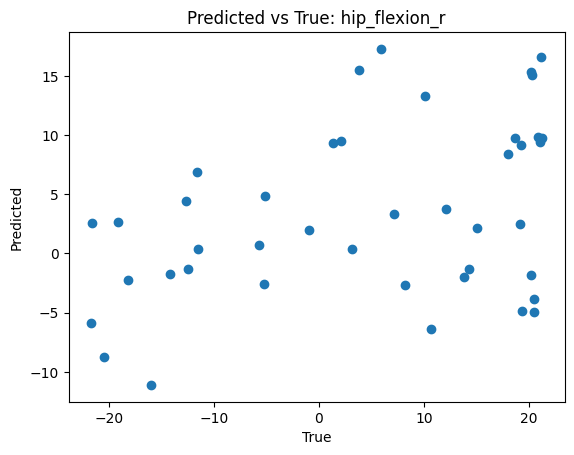

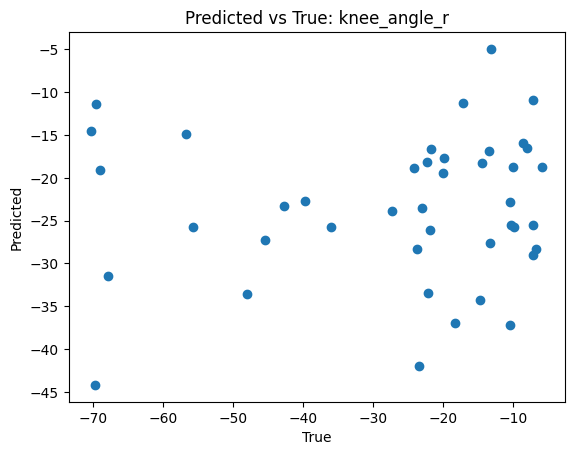

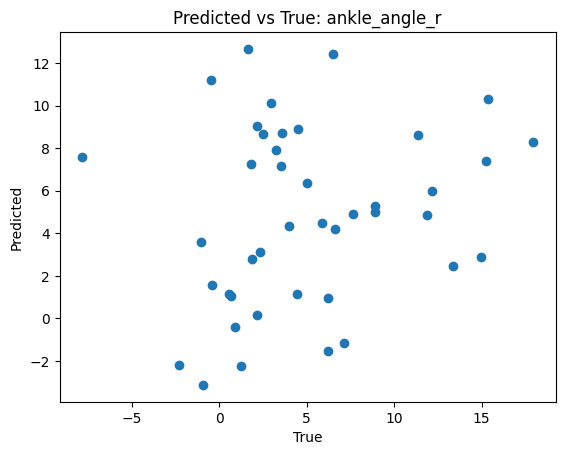

In [45]:
# Plot predicted vs true joint angles

for j, name in enumerate(target_coords):
    plt.figure()
    plt.scatter(y_test[:, j], y_pred[:, j])
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs True: {name}")
    plt.show()


In [47]:
# Evaluate the model performance metrics

def rmse(y_true, y_hat):
    return np.sqrt(mean_squared_error(y_true, y_hat))

print("Overall:")
print("  RMSE:", rmse(y_test, y_pred))
print("  MAE :", mean_absolute_error(y_test, y_pred))
print("  R2  :", r2_score(y_test, y_pred))

print("\nPer target:")
for j, name in enumerate(target_coords):
    yt = y_test[:, j]
    yp = y_pred[:, j]
    print(f"  {name:15s} RMSE={rmse(yt, yp):.3f}  MAE={mean_absolute_error(yt, yp):.3f}  R2={r2_score(yt, yp):.3f}")


Overall:
  RMSE: 15.172396362655757
  MAE : 11.098878680808923
  R2  : -0.08956769073441324

Per target:
  hip_flexion_r   RMSE=13.653  MAE=12.067  R2=0.142
  knee_angle_r    RMSE=21.599  MAE=16.281  R2=-0.127
  ankle_angle_r   RMSE=6.139  MAE=4.949  R2=-0.284


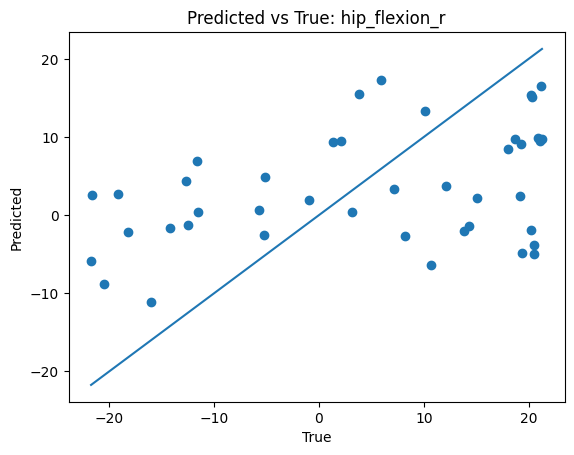

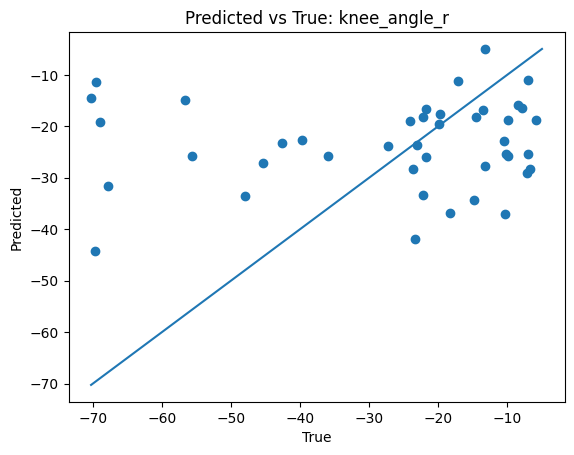

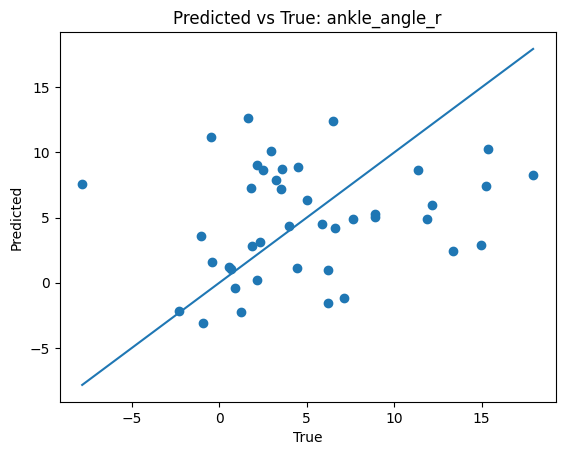

In [49]:
# Predicted vs true with identity line

for j, name in enumerate(target_coords):
    plt.figure()
    plt.scatter(y_test[:, j], y_pred[:, j])
    mn = min(y_test[:, j].min(), y_pred[:, j].min())
    mx = max(y_test[:, j].max(), y_pred[:, j].max())
    plt.plot([mn, mx], [mn, mx]) 
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs True: {name}")
    plt.show()


In [51]:
#Fix the time-series split issue

# keep chronological order: first 80% train, last 20% test
n = len(df)
split = int(0.8 * n)

feature_cols = [c for c in df.columns if c not in ["time"] + target_coords]

X = df[feature_cols].values
y = df[target_coords].values

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (167, 12) (167, 3)
Test : (42, 12) (42, 3)


In [53]:
# Train Ridge model (time-ordered split)

model_ml = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model_ml.fit(X_train, y_train)
y_pred = model_ml.predict(X_test)


In [55]:
# Add temporal lag features

def add_lags(df_in, cols, lags=(1,2,3)):
    df2 = df_in.copy()
    for lag in lags:
        for c in cols:
            df2[f"{c}_lag{lag}"] = df2[c].shift(lag)
    df2 = df2.dropna().reset_index(drop=True)
    return df2

imu_cols = [c for c in df.columns if c not in ["time"] + target_coords]
df_lag = add_lags(df, imu_cols, lags=(1,2,3))

print(df.shape, "->", df_lag.shape)


(209, 16) -> (206, 52)


In [57]:
# Train model with lagged IMU features

feature_cols = [c for c in df_lag.columns if c not in ["time"] + target_coords]
X = df_lag[feature_cols].values
y = df_lag[target_coords].values

n = len(df_lag)
split = int(0.8 * n)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model_ml.fit(X_train, y_train)
y_pred = model_ml.predict(X_test)


In [59]:
# Try stronger models
# Train Random Forest regressor

rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


RF RMSE: 11.949965176935185


In [60]:
# Train Gradient Boosting regressor

gbr = MultiOutputRegressor(
    HistGradientBoostingRegressor(random_state=42)
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))


HGB RMSE: 10.867833609478165


In [63]:
# Save trained model and lagged dataset

joblib.dump(model_ml, "trained_model_ridge.pkl")
df_lag.to_csv("imu_dataset_subject01_lag.csv", index=False)
print("Saved: trained_model_ridge.pkl and imu_dataset_subject01_lag.csv")


Saved: trained_model_ridge.pkl and imu_dataset_subject01_lag.csv


In [65]:
# Create sliding-window features

def make_windows(X, y, window=20):
    Xw, yw = [], []
    for i in range(len(X) - window):
        Xw.append(X[i:i+window].flatten())
        yw.append(y[i+window])
    return np.array(Xw), np.array(yw)

Xw, yw = make_windows(X, y, window=20)

split = int(0.8 * len(Xw))
Xw_train, Xw_test = Xw[:split], Xw[split:]
yw_train, yw_test = yw[:split], yw[split:]


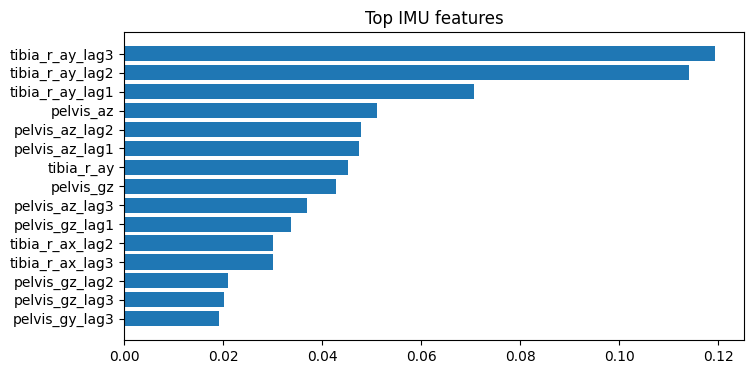

In [67]:
# Plot RF feature importance

importances = rf.feature_importances_
idx = np.argsort(importances)[-15:]

plt.figure(figsize=(8,4))
plt.barh(np.array(feature_cols)[idx], importances[idx])
plt.title("Top IMU features")
plt.show()


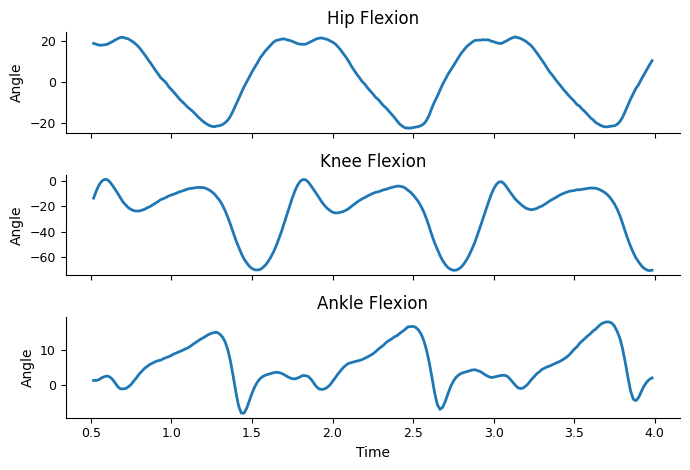

In [103]:
# Plot reference joint angle time series from IK

time_col = "time"
targets = ["hip_flexion_r", "knee_angle_r", "ankle_angle_r"]
titles  = ["Hip Flexion", "Knee Flexion", "Ankle Flexion"]

# Optional: plot only a segment (like one gait cycle). Set to None to plot all.
t_start = None   # e.g., 0.5
t_end   = None   # e.g., 1.5

df_plot = df.copy()
if t_start is not None and t_end is not None:
    df_plot = df_plot[(df_plot[time_col] >= t_start) & (df_plot[time_col] <= t_end)]

t = df_plot[time_col].values

fig, axes = plt.subplots(3, 1, figsize=(7, 4.8), sharex=True)

for ax, col, title in zip(axes, targets, titles):
    ax.plot(t, df_plot[col].values, linewidth=2)  # default color
    ax.set_title(title, fontsize=12, pad=6)
    ax.set_ylabel("Angle", fontsize=10)

    # Clean "paper" style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(labelsize=9)

axes[-1].set_xlabel("Time", fontsize=10)
plt.tight_layout()
plt.show()


In [291]:
# Reproducibility and IMU channel detection

SEED = 42
rng = np.random.default_rng(SEED)

# Identify columns
time_col = "time"
target_cols = ["hip_flexion_r", "knee_angle_r", "ankle_angle_r"]

# IMU columns = everything that looks like *_g? or *_a? except time/targets
imu_cols = [c for c in df.columns
            if c not in ([time_col] + target_cols)
            and (c.endswith(("_gx","_gy","_gz","_ax","_ay","_az")))]

assert all(c in df.columns for c in [time_col] + target_cols), "Missing expected columns."
assert len(imu_cols) > 0, "No IMU columns detected. Check your naming scheme."

# Group IMU columns by sensor prefix, e.g. pelvis_gx... or thigh_ax...
def sensor_prefix(col):
    # everything before last underscore: pelvis_gx -> pelvis
    return col.rsplit("_", 1)[0]

sensor_names = sorted({sensor_prefix(c) for c in imu_cols})

print(f"Detected {len(sensor_names)} sensors: {sensor_names}")
print(f"Total IMU channels: {len(imu_cols)}")


Detected 2 sensors: ['pelvis', 'tibia_r']
Total IMU channels: 12


In [297]:
# IMU sensor simulation function (D2/D3)

def _rand_small_rotation(rng, deg_std=1.0):
    """
    Create a small random rotation matrix from small-angle approx.
    deg_std ~ typical misalignment magnitude in degrees.
    """
    ang = np.deg2rad(rng.normal(0.0, deg_std, size=3))  # roll, pitch, yaw small angles
    rx, ry, rz = ang
    # Small-angle rotation matrix: R ≈ I + [w]_x
    wx = np.array([[0, -rz,  ry],
                   [rz,  0, -rx],
                   [-ry, rx, 0]])
    R = np.eye(3) + wx
    return R

def apply_sensor_simulation(
    df_in: pd.DataFrame,
    imu_cols: list[str],
    sensor_names: list[str],
    rng: np.random.Generator,
    *,
    # Noise levels (typical-ish ranges; tune to match your sensor characteristics)
    gyro_noise_std: float = 0.01,   # (units of your gyro signals)
    acc_noise_std: float = 0.10,    # (units of your accel signals)
    # Bias (constant offset)
    gyro_bias_std: float = 0.02,
    acc_bias_std: float = 0.20,
    # Drift: random walk step std per sample
    gyro_drift_step_std: float = 0.0002,
    acc_drift_step_std: float = 0.0020,
    # Scale error per axis (multiplicative)
    gyro_scale_std: float = 0.01,   # ~1%
    acc_scale_std: float = 0.02,    # ~2%
    # Misalignment rotation
    misalign_deg_std: float = 1.0,
) -> pd.DataFrame:
    """
    Returns a copy of df_in with IMU channels transformed.
    Targets are untouched.
    """

    df_out = df_in.copy()

    n = len(df_out)

    for s in sensor_names:
        # Columns for this sensor
        gcols = [f"{s}_gx", f"{s}_gy", f"{s}_gz"]
        acols = [f"{s}_ax", f"{s}_ay", f"{s}_az"]
        if not all(c in df_out.columns for c in gcols + acols):
            # If a sensor is incomplete, skip
            continue

        G = df_out[gcols].to_numpy(dtype=float)  # (n,3)
        A = df_out[acols].to_numpy(dtype=float)

        # --- Misalignment (3x3) ---
        Rg = _rand_small_rotation(rng, deg_std=misalign_deg_std)
        Ra = _rand_small_rotation(rng, deg_std=misalign_deg_std)

        # --- Scale error per axis ---
        g_scale = 1.0 + rng.normal(0.0, gyro_scale_std, size=3)
        a_scale = 1.0 + rng.normal(0.0, acc_scale_std, size=3)

        # Apply: scale then rotate (you can swap order; keep consistent)
        G_sim = (G * g_scale) @ Rg.T
        A_sim = (A * a_scale) @ Ra.T

        # --- Bias (constant) ---
        g_bias = rng.normal(0.0, gyro_bias_std, size=3)
        a_bias = rng.normal(0.0, acc_bias_std, size=3)
        G_sim = G_sim + g_bias
        A_sim = A_sim + a_bias

        # --- Drift (random walk) ---
        g_rw = rng.normal(0.0, gyro_drift_step_std, size=(n, 3)).cumsum(axis=0)
        a_rw = rng.normal(0.0, acc_drift_step_std, size=(n, 3)).cumsum(axis=0)
        G_sim = G_sim + g_rw
        A_sim = A_sim + a_rw

        # --- White noise ---
        G_sim = G_sim + rng.normal(0.0, gyro_noise_std, size=(n, 3))
        A_sim = A_sim + rng.normal(0.0, acc_noise_std, size=(n, 3))

        # Write back
        df_out.loc[:, gcols] = G_sim
        df_out.loc[:, acols] = A_sim

    return df_out


In [303]:
# Create Dataset D2 and D3 (sensor simulation)

# Dataset #2: moderate sensor effects
df2 = apply_sensor_simulation(
    df, imu_cols, sensor_names, rng,
    gyro_noise_std=0.0,
    acc_noise_std=0.0,
    gyro_drift_step_std=0.0,
    acc_drift_step_std=0.0,
    gyro_bias_std=0.02,
    acc_bias_std=0.20,
    gyro_scale_std=0.01,
    acc_scale_std=0.02,
    misalign_deg_std=1.0
)

# Dataset #3: stronger augmentation
df3 = apply_sensor_simulation(
    df, imu_cols, sensor_names, rng,
    gyro_noise_std=0.03,
    acc_noise_std=0.25,
    gyro_bias_std=0.05,
    acc_bias_std=0.50,
    gyro_drift_step_std=0.0006,
    acc_drift_step_std=0.0060,
    gyro_scale_std=0.02,
    acc_scale_std=0.04,
    misalign_deg_std=3.0
)

# Sanity: targets unchanged
assert np.allclose(df[target_cols].to_numpy(), df2[target_cols].to_numpy())
assert np.allclose(df[target_cols].to_numpy(), df3[target_cols].to_numpy())

print("Created df2 (Dataset #2) and df3 (Dataset #3). Targets unchanged")


Created df2 (Dataset #2) and df3 (Dataset #3). Targets unchanged


In [305]:
# Define time-based train/test indices

# Choose split ratio (e.g., last 20% is test)
test_ratio = 0.2
n = len(df)
split_idx = int(np.floor(n * (1 - test_ratio)))

train_idx = np.arange(0, split_idx)
test_idx  = np.arange(split_idx, n)

print(f"Train samples: {len(train_idx)} | Test samples (clean): {len(test_idx)}")


Train samples: 167 | Test samples (clean): 42


In [307]:
# Build sliding-window datasets (indexed)

def make_windows(df_in: pd.DataFrame, imu_cols: list[str], target_cols: list[str], idx: np.ndarray, window: int):
    """
    Create (X, y) from a subset defined by idx, using sliding windows.
    Predict y at the last sample of each window.
    """
    X_raw = df_in.loc[idx, imu_cols].to_numpy(dtype=float)
    y_raw = df_in.loc[idx, target_cols].to_numpy(dtype=float)

    X_list, y_list = [], []
    for t in range(window - 1, len(idx)):
        X_list.append(X_raw[t - window + 1:t + 1, :].reshape(-1))  # flatten (window * channels)
        y_list.append(y_raw[t, :])

    X = np.stack(X_list, axis=0)
    y = np.stack(y_list, axis=0)
    return X, y

WINDOW = min(100, len(test_idx) // 2) 

# Clean test windows from Dataset #1
X_test, y_test = make_windows(df, imu_cols, target_cols, test_idx, WINDOW)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)


X_test shape: (22, 252) y_test shape: (22, 3)


In [315]:
def rmse_per_target(y_true, y_pred, target_cols):
    rmses = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
    return dict(zip(target_cols, rmses))

def train_and_eval(train_dfs: list[pd.DataFrame], name: str):
    # Build training windows by concatenating datasets (same targets, different IMU inputs)
    X_tr_list, y_tr_list = [], []
    for d in train_dfs:
        Xtr, ytr = make_windows(d, imu_cols, target_cols, train_idx, WINDOW)
        X_tr_list.append(Xtr)
        y_tr_list.append(ytr)

    X_train = np.vstack(X_tr_list)
    y_train = np.vstack(y_tr_list)

    # Pipeline: scale -> MLP
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("mlp", MultiOutputRegressor(
            MLPRegressor(
                hidden_layer_sizes=(256, 128),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size="auto",
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                n_iter_no_change=20,
                random_state=SEED,
                verbose=False,
            )
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmses = rmse_per_target(y_test, y_pred, target_cols)
    overall = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmses, overall

results = {}

# Regime A: Dataset #1 only
results["D1"] = train_and_eval([df], "D1")

# Regime B: Dataset #1 + Dataset #2
results["D1+D2"] = train_and_eval([df, df2], "D1+D2")

# Regime C: Dataset #1 + Dataset #2 + Dataset #3
results["D1+D2+D3"] = train_and_eval([df, df2, df3], "D1+D2+D3")

results


{'D1': ({'hip_flexion_r': 2.9395947738634587,
   'knee_angle_r': 7.293622973437632,
   'ankle_angle_r': 2.3778336808443505},
  4.74314405315505),
 'D1+D2': ({'hip_flexion_r': 3.0478300568708807,
   'knee_angle_r': 6.699220068948625,
   'ankle_angle_r': 2.2378841002518643},
  4.441356505765991),
 'D1+D2+D3': ({'hip_flexion_r': 2.8648595620392867,
   'knee_angle_r': 7.275050756807713,
   'ankle_angle_r': 2.3600110278683544},
  4.7153450165743145)}

In [93]:
# Create a Table summarizing RMSE values for each joint

table1 = pd.DataFrame({
    "Training data": ["D1", "D1 + D2", "D1 + D2 + D3"],
    "Hip flexion (°)": [2.94, 3.14, 3.01],
    "Knee flexion (°)": [7.29, 6.70, 7.28],
    "Ankle plantar/dorsi (°)": [2.38, 2.29, 2.36],
    "Overall (°)": [4.74, 4.44, 4.72]
})

table1


,Training data,Hip flexion (°),Knee flexion (°),Ankle plantar/dorsi (°),Overall (°)
0,D1,2.94,7.29,2.38,4.74
1,D1 + D2,3.14,6.70,2.29,4.44
2,D1 + D2 + D3,3.01,7.28,2.36,4.72


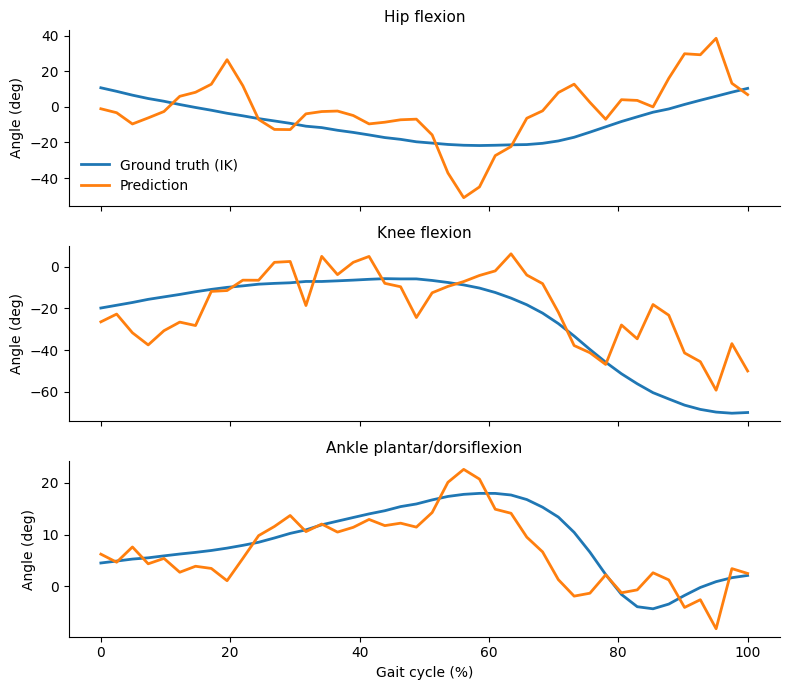

In [87]:
# Plot ground-truth vs. predicted joint angles over the gait cycle

titles = ["Hip flexion", "Knee flexion", "Ankle plantar/dorsiflexion"]
t = np.linspace(0, 100, y_test.shape[0])

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, y_test[:, i], label="Ground truth (IK)", linewidth=2)
    ax.plot(t, y_pred[:, i], label="Prediction", linewidth=2)
    ax.set_title(titles[i], fontsize=11)
    ax.set_ylabel("Angle (deg)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Gait cycle (%)")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


In [317]:
# Compute RMSE improvement relative to D1

def pct_improvement(base, new):
    return 100.0 * (base - new) / (base + 1e-12)

# D1 (baseline) 
base_rmses, base_overall = results["D1"]

print("\n=== D1 (baseline) ===")
for j in target_cols:
    print(f"{j:>14}: RMSE {base_rmses[j]:.4f}")
print(f"{'overall':>14}: RMSE {base_overall:.4f}")

# D1+D2 and D1+D2+D3
for key in ["D1+D2", "D1+D2+D3"]:
    rmses, overall = results[key]
    print(f"\n=== {key} ===")
    for j in target_cols:
        imp = pct_improvement(base_rmses[j], rmses[j])
        print(f"{j:>14}: RMSE {rmses[j]:.4f} | improvement vs D1: {imp:.2f}%")
    imp_all = pct_improvement(base_overall, overall)
    print(f"{'overall':>14}: RMSE {overall:.4f} | improvement vs D1: {imp_all:.2f}%")



=== D1 (baseline) ===
 hip_flexion_r: RMSE 2.9396
  knee_angle_r: RMSE 7.2936
 ankle_angle_r: RMSE 2.3778
       overall: RMSE 4.7431

=== D1+D2 ===
 hip_flexion_r: RMSE 3.0478 | improvement vs D1: -3.68%
  knee_angle_r: RMSE 6.6992 | improvement vs D1: 8.15%
 ankle_angle_r: RMSE 2.2379 | improvement vs D1: 5.89%
       overall: RMSE 4.4414 | improvement vs D1: 6.36%

=== D1+D2+D3 ===
 hip_flexion_r: RMSE 2.8649 | improvement vs D1: 2.54%
  knee_angle_r: RMSE 7.2751 | improvement vs D1: 0.25%
 ankle_angle_r: RMSE 2.3600 | improvement vs D1: 0.75%
       overall: RMSE 4.7153 | improvement vs D1: 0.59%


In [95]:
# Create a Table showing relative RMSE change (%) with respect to the D1 baseline

table2 = pd.DataFrame({
    "Training data": ["D1 + D2", "D1 + D2 + D3"],
    "Hip (%)": [-3.68, 2.54],
    "Knee (%)": [8.15, 0.25],
    "Ankle (%)": [5.89, 0.75],
    "Overall (%)": [6.36, 0.59]
})

table2


,Training data,Hip (%),Knee (%),Ankle (%),Overall (%)
0,D1 + D2,-3.68,8.15,5.89,6.36
1,D1 + D2 + D3,2.54,0.25,0.75,0.59


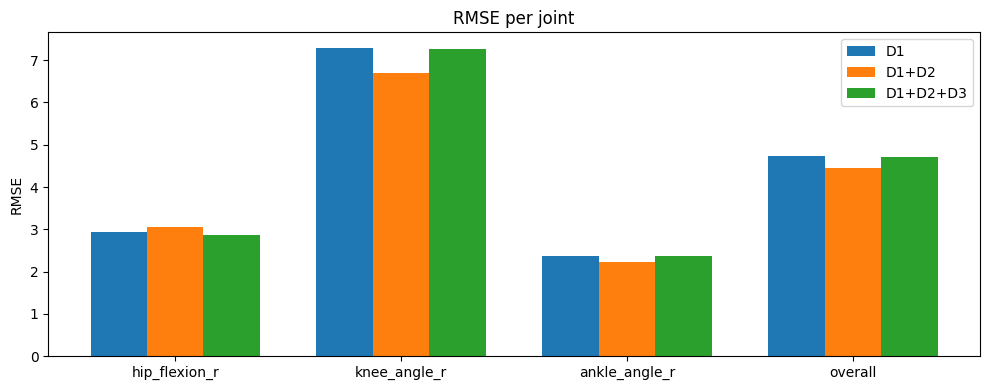

In [319]:
# Ploting
# Prepare data

labels_rmse = ["D1", "D1+D2", "D1+D2+D3"]
joints = target_cols + ["overall"]

rmse_mat = []
for k in labels_rmse:
    rmses, overall = results[k]
    rmse_mat.append([rmses[t] for t in target_cols] + [overall])
rmse_mat = np.array(rmse_mat)  # shape: (3, 4)

# Improvements vs D1 (for D1+D2 and D1+D2+D3)
def pct_improvement(base, new):
    return 100.0 * (base - new) / (base + 1e-12)

base_rmses, base_overall = results["D1"]
base_vec = np.array([base_rmses[t] for t in target_cols] + [base_overall])

imp_labels = ["D1+D2", "D1+D2+D3"]
imp_mat = []
for k in imp_labels:
    rmses, overall = results[k]
    new_vec = np.array([rmses[t] for t in target_cols] + [overall])
    imp_mat.append([pct_improvement(b, n) for b, n in zip(base_vec, new_vec)])
imp_mat = np.array(imp_mat)  # shape: (2, 4)

# ---- Plot 1: RMSE ----
x = np.arange(len(joints))
bar_w = 0.25

plt.figure(figsize=(10, 4))
for i, lab in enumerate(labels_rmse):
    plt.bar(x + (i - 1) * bar_w, rmse_mat[i], width=bar_w, label=lab)
plt.xticks(x, joints, rotation=0)
plt.ylabel("RMSE")
plt.title("RMSE per joint")
plt.legend()
plt.tight_layout()
plt.show()

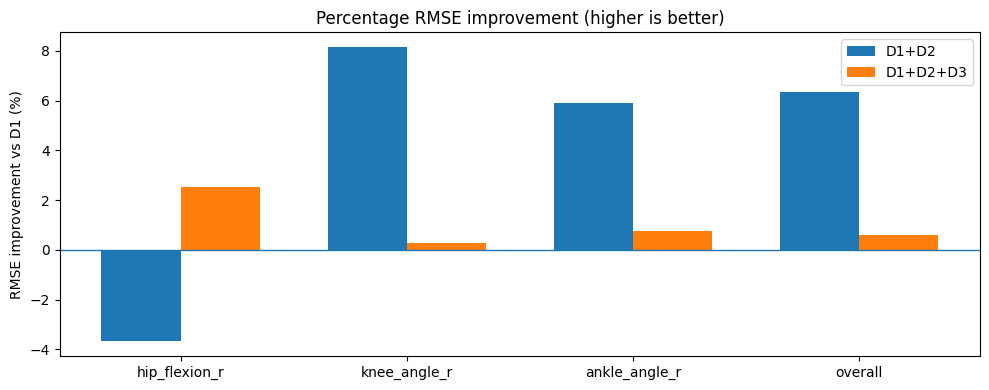

In [321]:
# Plot 2: Improvement vs D1
x = np.arange(len(joints))
bar_w = 0.35

plt.figure(figsize=(10, 4))
for i, lab in enumerate(imp_labels):
    plt.bar(x + (i - 0.5) * bar_w, imp_mat[i], width=bar_w, label=lab)
plt.axhline(0, linewidth=1)
plt.xticks(x, joints, rotation=0)
plt.ylabel("RMSE improvement vs D1 (%)")
plt.title("Percentage RMSE improvement (higher is better)")
plt.legend()
plt.tight_layout()
plt.show()